In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-pastel")

sns.set_theme(
    style="whitegrid",
    palette="pastel",
    context="notebook"
)

In [45]:
df = pd.read_csv("top_250_imdb_dataset.csv")

In [46]:
df.head()

,Rank,Title,Year,Rating,Duration_Minutes,Certificate,Source
0,1,The Shawshank Redemption,1994,NaN,142,R,IMDb Top 250
1,2,The Godfather,1972,NaN,175,R,IMDb Top 250
2,3,The Dark Knight,2008,NaN,152,PG-13,IMDb Top 250
3,4,The Godfather Part II,1974,NaN,202,R,IMDb Top 250
4,5,12 Angry Men,1957,NaN,96,Approved,IMDb Top 250


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              250 non-null    int64  
 1   Title             250 non-null    object 
 2   Year              250 non-null    int64  
 3   Rating            0 non-null      float64
 4   Duration_Minutes  250 non-null    int64  
 5   Certificate       245 non-null    object 
 6   Source            250 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 13.8+ KB


In [48]:
#drop rank,rating and source
df.drop("Rating",axis=1,inplace=True)
df.drop("Rank",axis=1,inplace=True)
df.drop("Source",axis=1,inplace=True)

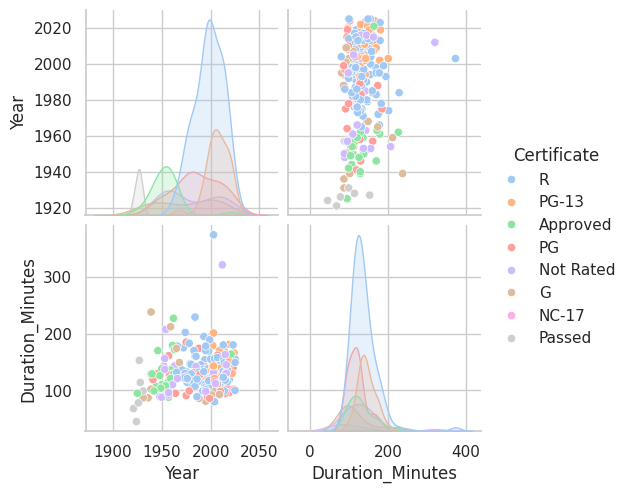

In [49]:
#pairplot
sns.pairplot(df,hue="Certificate")
plt.show()

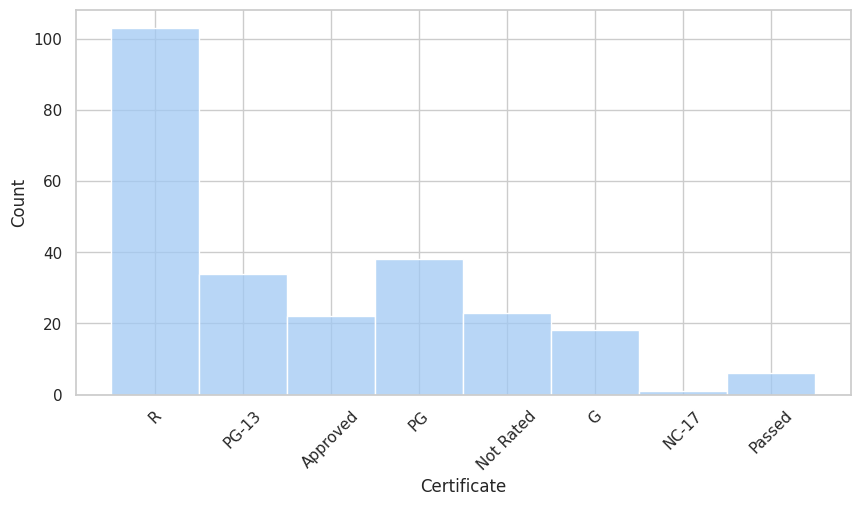

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(df["Certificate"])
plt.xticks(rotation=45)
plt.show()

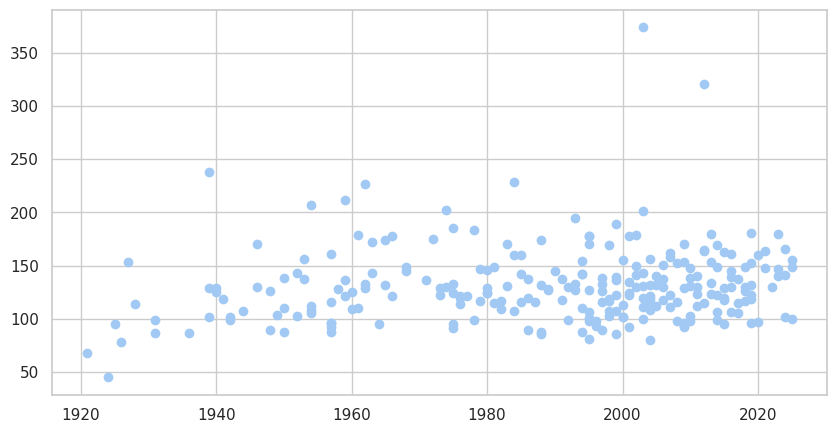

In [51]:
plt.figure(figsize=(10,5))
plt.scatter(df["Year"],df["Duration_Minutes"])
plt.show()

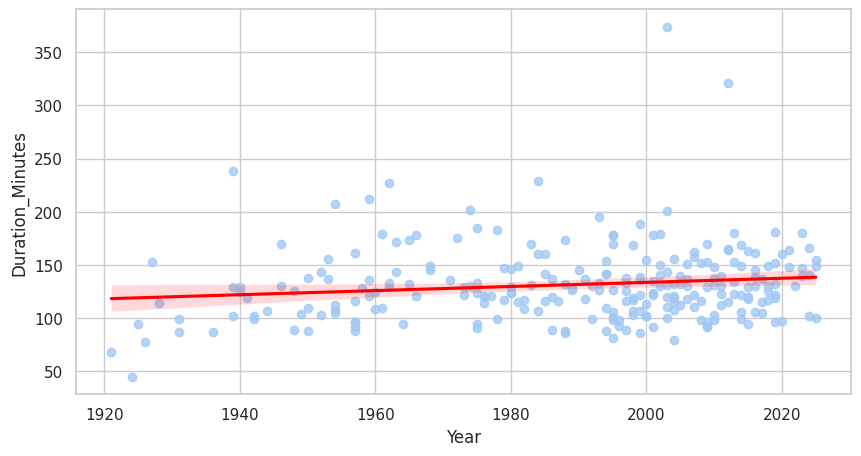

In [52]:
#regplot year vs duration
plt.figure(figsize=(10,5))
sns.regplot(x=df["Year"],y=df["Duration_Minutes"],line_kws={"color":"red"})
plt.show()

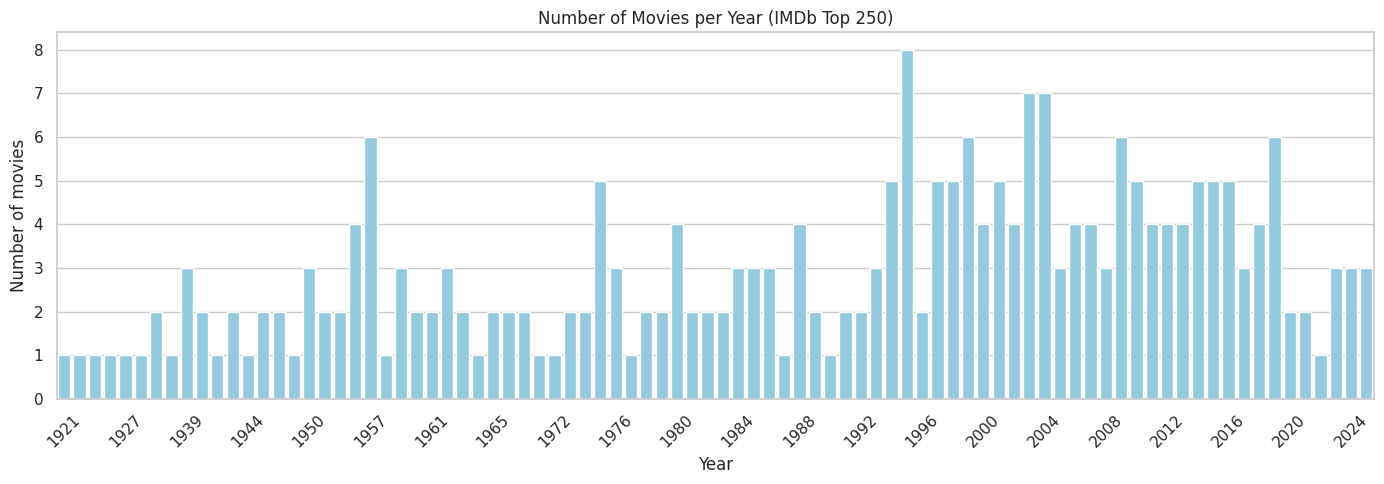

In [60]:
#movies per year visulization
movies_per_year = df["Year"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=movies_per_year.index, y=movies_per_year.values, color="skyblue")
plt.title("Number of Movies per Year (IMDb Top 250)")
plt.xlabel("Year")
plt.ylabel("Number of movies")

step = max(len(movies_per_year) // 20, 1)
plt.xticks(ticks=range(0, len(movies_per_year), step),
           labels=movies_per_year.index[::step],
           rotation=45)

plt.tight_layout()
plt.show()